# Kuhn Poker 3: CFR, ISMCTS, ISMCTS

## Características de la variante de 3 jugadores

El juego mantiene la misma esencia simplificada, pero ajusta los componentes necesarios para dar cabida al tercer participante:

* **El mazo aumenta a 4 cartas:**
  Por lo general, se juega utilizando un **As (A)**, **Rey (K)**, **Reina (Q)** y **Jota (J)**.
  El As es la carta más alta y la Jota la más baja.

* **El reparto:**
  Cada uno de los tres jugadores recibe una única carta oculta.
  La cuarta carta restante se descarta boca abajo y no se revela.

* **Apuestas:**
  Todos colocan una apuesta inicial obligatoria, conocida como **ante**.
  Solo existe una ronda de apuestas, donde los jugadores eligen entre **pasar (check)** o **apostar su ficha restante**.


In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import permutations
from matplotlib.ticker import FuncFormatter, NullFormatter

from games.kuhn.kuhn3 import KuhnPoker3
from agents.agent_random import RandomAgent
from agents.counterfactualregret import CounterFactualRegret
from agents.ismcts import InformationSetMCTS

game = KuhnPoker3(play_order=[0, 1, 2])
game.reset()

FIGURES_DIR = os.path.join('..', 'informe', 'figures', 'KuhnPoker3')
os.makedirs(FIGURES_DIR, exist_ok=True)

def savefig(fig, name):
    path = os.path.join(FIGURES_DIR, name)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f'Guardada: {path}')

PLAIN = FuncFormatter(lambda v, _: f'{v:g}')

def log_xticks(ax, ticks):
    ax.set_xticks(ticks)
    ax.xaxis.set_major_formatter(PLAIN)
    ax.xaxis.set_minor_formatter(NullFormatter())

def kuhn3_sample(g, agent):
    return g.sample_from_infoset(agent)

def train_alternated(*agents, total_iters, block=100):
    for _ in range(total_iters // block):
        for ag in agents:
            ag.train(block)
    rem = total_iters % block
    if rem:
        for ag in agents:
            ag.train(rem)

def cfr_expected_reward(node_dict, game_ref, target_agent):
    def tree_ev(g):
        if g.terminated():
            return g.reward(target_agent)
        curr = g.agent_selection
        node = node_dict.get(g.observe(curr))
        n_act = g.num_actions(curr)
        policy = node.policy() if node else np.full(n_act, 1 / n_act)
        total = 0.0
        for a in range(n_act):
            ng = g.clone()
            ng.step(a)
            total += policy[a] * tree_ev(ng)
        return total

    deals = list(permutations(game_ref._cards, game_ref.num_agents))
    total = 0.0
    for deal in deals:
        g = game_ref.clone()
        g.reset()
        g._hand = np.array(deal)
        total += tree_ev(g)
    return total / len(deals)

## Demo: una partida con agentes aleatorios

In [2]:
rnds = {a: RandomAgent(game=game, agent=a) for a in game.agents}
game.reset()
game.render()
while not game.terminated():
    a = rnds[game.agent_selection].action()
    game.step(a)
game.render()
print('Rewards:', game.rewards)

agent_0 J 
agent_1 K 
agent_2 A 
agent_0 J ppp
agent_1 K ppp
agent_2 A ppp
Rewards: {'agent_0': np.int64(-1), 'agent_1': np.int64(-1), 'agent_2': np.int64(2)}


## Experimento 1 — CFR en auto-juego: tres agentes

Se entrenan tres agentes CFR con `node_dict` compartido usando entrenamiento alternado en bloques.
El reward esperado de cada agente se calcula analíticamente (sin simulación) recorriendo
el árbol con las políticas aprendidas.

Al aumentar las iteraciones, los tres agentes deberían converger al equilibrio de Nash.

Guardada: ../informe/figures/KuhnPoker3/cfr3_autoplay.png


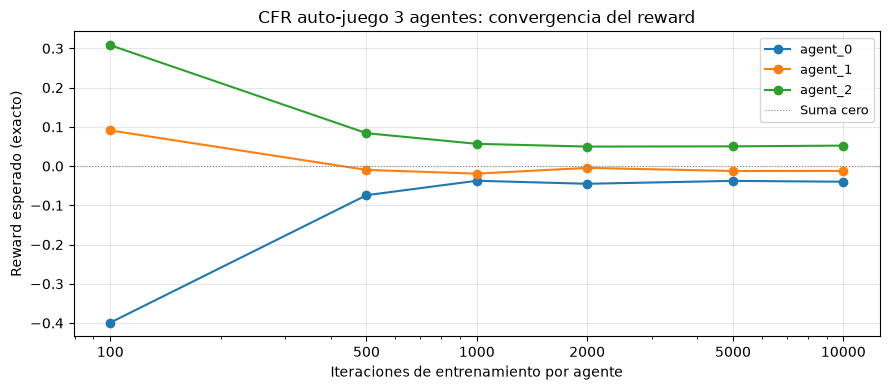

agente  agent_0  agent_1  agent_2
iters                            
100     -0.3990   0.0909   0.3081
500     -0.0742  -0.0097   0.0839
1000    -0.0374  -0.0193   0.0567
2000    -0.0451  -0.0046   0.0497
5000    -0.0377  -0.0125   0.0503
10000   -0.0399  -0.0123   0.0522


In [3]:
checkpoints = [100, 500, 1000, 2000, 5000, 10_000]

c0 = CounterFactualRegret(game=game, agent='agent_0')
c1 = CounterFactualRegret(game=game, agent='agent_1')
c2 = CounterFactualRegret(game=game, agent='agent_2')
c1.node_dict = c0.node_dict
c2.node_dict = c0.node_dict

history = {a: [] for a in game.agents}
prev = 0
for ck in checkpoints:
    train_alternated(c0, c1, c2, total_iters=ck - prev, block=min(100, ck - prev))
    prev = ck
    shared = c0.node_dict
    for ag in game.agents:
        history[ag].append(cfr_expected_reward(shared, game, ag))

rows = []
for ag in game.agents:
    for ck, val in zip(checkpoints, history[ag]):
        rows.append(dict(agente=ag, iters=ck, avg_reward=round(val, 4)))
df_exp1 = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 4))
colors = {'agent_0': 'tab:blue', 'agent_1': 'tab:orange', 'agent_2': 'tab:green'}
for ag in game.agents:
    vals = [r['avg_reward'] for r in rows if r['agente'] == ag]
    ax.plot(checkpoints, vals, marker='o', label=ag, color=colors[ag])
ax.axhline(0, color='gray', linestyle=':', linewidth=0.8, label='Suma cero')
ax.set_xscale('log')
log_xticks(ax, checkpoints)
ax.set_xlabel('Iteraciones de entrenamiento por agente')
ax.set_ylabel('Reward esperado (exacto)')
ax.set_title('CFR auto-juego 3 agentes: convergencia del reward')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
savefig(fig, 'cfr3_autoplay.png')
plt.show()

print(df_exp1.pivot(index='iters', columns='agente', values='avg_reward').to_string())

## Experimento 2 — ISMCTS en auto-juego: efecto del número de simulaciones

Tres agentes ISMCTS juegan entre sí variando `simulations`.
ISMCTS es un algoritmo online: no requiere entrenamiento previo; en cada turno
construye un árbol de búsqueda usando determinizaciones aleatorias de las cartas rivales.

Se mide el reward promedio de cada agente en función de las simulaciones por decisión.

In [ ]:
N = 200
sim_grid = [5, 10, 25, 50, 100, 200]
colors = {'agent_0': 'tab:blue', 'agent_1': 'tab:orange', 'agent_2': 'tab:green'}

rows = []
for sims in sim_grid:
    agents = {
        a: InformationSetMCTS(game=game, agent=a, simulations=sims,
                              rollouts=3, sample_from_infoset=kuhn3_sample)
        for a in game.agents
    }
    rewards = {a: [] for a in game.agents}
    for _ in range(N):
        game.reset()
        while not game.terminated():
            a = agents[game.agent_selection].action()
            game.step(a)
        for ag in game.agents:
            rewards[ag].append(game.reward(ag))

    for ag in game.agents:
        r = np.array(rewards[ag])
        rows.append(dict(agente=ag, sims=sims, avg_reward=round(r.mean(), 4)))
    print(f'sims={sims}: ' + '  '.join(f'{ag}={np.mean(rewards[ag]):.3f}' for ag in game.agents))

df_exp2 = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 4))
for ag in game.agents:
    vals = df_exp2[df_exp2.agente == ag]
    ax.plot(vals.sims, vals.avg_reward, marker='o', label=ag, color=colors[ag])
ax.axhline(0, color='gray', linestyle=':', linewidth=0.8, label='Suma cero')
ax.set_xlabel('Simulaciones por decisión')
ax.set_ylabel('Reward promedio')
ax.set_title(f'ISMCTS auto-juego 3 agentes (N={N} partidas)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
savefig(fig, 'ismcts3_autoplay.png')
plt.show()

df_exp2.pivot(index='sims', columns='agente', values='avg_reward')